# Dataset analysis (Toys_and_Games)

In [1]:
import csv
import json
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

## 1. Read .inter file

In [2]:
df = pd.read_csv('../../Amazon_Toys_and_Games/Amazon_Toys_and_Games.inter', sep='\t')

df.head(5)

,user_id:token,item_id:token,rating:float,timestamp:float
0,0,0,5.0,1390953600
1,1,0,4.0,1395964800
2,2,0,5.0,1359331200
3,3,0,5.0,1391817600
4,4,0,4.0,1399248000


## 2. K-core filtering

In [3]:
while True:
    shp = df.shape

    df = df.groupby("user_id:token").filter(lambda x: len(x) >= 5)
    df = df.groupby("item_id:token").filter(lambda x: len(x) >= 5)

    if df.shape == shp:
        break

    print(f"Number of unique items: {df['item_id:token'].nunique()}")
    print(f"Number of unique users: {df['user_id:token'].nunique()}")
    print(df.shape)

## 3. Analysis

### 3.1 Number of unique users & items

In [4]:
print(f"Number of unique items: {df['item_id:token'].nunique()}")
print(f"Number of unique users: {df['user_id:token'].nunique()}")
print(f"Number of unique reviews: {df.shape[0]}")

Number of unique items: 11924
Number of unique users: 19412
Number of unique reviews: 167597


### 3.2 Averages

In [5]:
print(f"Average rating: {df['rating:float'].sum() / df.shape[0]}")
print(f"Average interaction of user: {df.shape[0] / df['user_id:token'].nunique()}")
print(f"Average interaction of item: {df.shape[0] / df['item_id:token'].nunique()}")

Average rating: 4.356307093802395
Average interaction of user: 8.633680197815783
Average interaction of item: 14.055434417980543


### 3.3 Interaction matrix sparsity

In [6]:
print(f"Matrix sparsity: {(1.0 - (df.shape[0] / (df['item_id:token'].nunique() * df['user_id:token'].nunique())))*100}%")

Matrix sparsity: 99.92759409428199%


### 3.4 Top 10 reviewers

In [7]:
user_counts = df.groupby("user_id:token").size().reset_index(name="review_count")
user_counts.sort_values('review_count', ascending=False).head(10)

,user_id:token,review_count
472,472,550
808,808,168
81,81,157
3889,3889,151
1920,1920,133
8089,8089,117
297,297,117
850,850,116
249,249,116
1054,1054,114


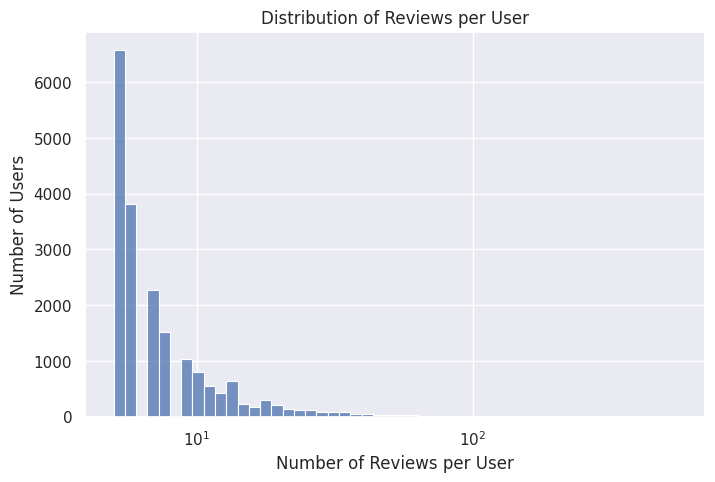

In [8]:
plt.figure(num=0, figsize=(8, 5))
sns.set_theme(style="darkgrid")

sns.histplot(
    user_counts['review_count'], 
    bins=50, log_scale=True
)

plt.xlabel("Number of Reviews per User")
plt.ylabel("Number of Users")
plt.title("Distribution of Reviews per User")

plt.show()

### 3.5 Top 10 reviewed items

In [9]:
product_counts = df.groupby(["item_id:token"]).size().reset_index(name="review_count")
product_counts.sort_values(by="review_count", ascending=False).head(10)

,item_id:token,review_count
7248,7248,309
9461,9461,253
5439,5439,215
4259,4259,207
4706,4706,196
2460,2460,194
2540,2540,192
2993,2993,191
11404,11404,184
1918,1918,170


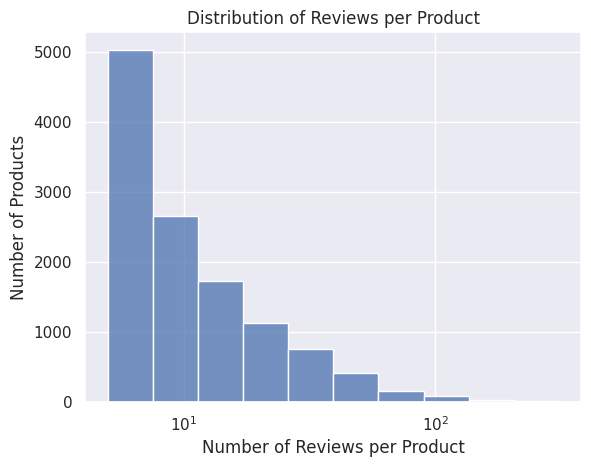

In [10]:
plt.figure(num=1)
sns.set_theme(style="darkgrid")

sns.histplot(
    data=product_counts['review_count'], 
    bins=10,
    log_scale=True
)

plt.xlabel("Number of Reviews per Product")
plt.ylabel("Number of Products")
plt.title("Distribution of Reviews per Product")

plt.show()

### 3.6 Item lifespan

In [11]:
lifespan_df = df.groupby(by='item_id:token')['timestamp:float'].agg(['min', 'max'])
lifespan_df['max'] = pd.to_datetime(lifespan_df['max'], unit='s')
lifespan_df['min'] = pd.to_datetime(lifespan_df['min'], unit='s')

lifespan_df['lifespan'] = lifespan_df['max'] - lifespan_df['min']
lifespan_df['lifespan'] = lifespan_df['lifespan'].dt.days

lifespan_df = lifespan_df[lifespan_df['lifespan'] != 0]
lifespan_df.head(5)

,min,max,lifespan
item_id:token,,,
0,2009-11-19,2014-05-24,1647
1,2008-05-30,2014-01-02,2043
2,2013-09-25,2014-04-15,202
3,2011-12-06,2014-04-02,848
4,2008-10-16,2014-05-21,2043


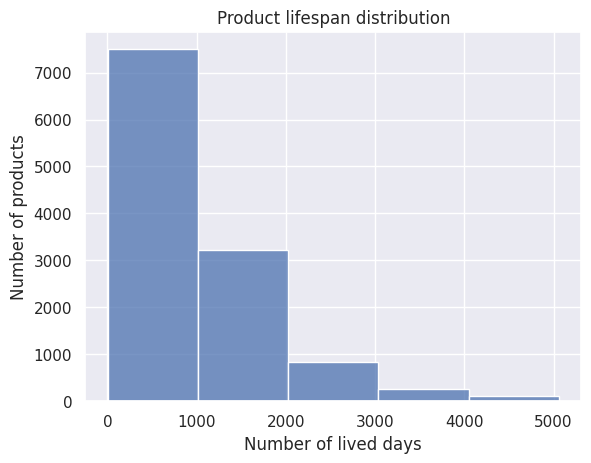

In [12]:
plt.figure(num=3)
sns.histplot(
    lifespan_df['lifespan'],
    log_scale=False,
    bins=5
)
plt.xlabel("Number of lived days")
plt.ylabel("Number of products")
plt.title("Product lifespan distribution")
plt.show()

### 3.7 Seasonality of items

In [13]:
seasonality_df = df.copy()
seasonality_df['timestamp:float'] = pd.to_datetime(seasonality_df['timestamp:float'], unit='s')
seasonality_df.set_index('timestamp:float', inplace=True)
seasonality_df.head()

,user_id:token,item_id:token,rating:float
timestamp:float,,,
2014-01-29,0,0,5.0
2014-03-28,1,0,4.0
2013-01-28,2,0,5.0
2014-02-08,3,0,5.0
2014-05-05,4,0,4.0


In [14]:
seasonality_df['verified_purchase'] = [True for _ in range(seasonality_df.shape[0])]
monthly_transaction_count = seasonality_df['verified_purchase'].resample('MS').count().reset_index(name="purchase_count")
monthly_transaction_count.head(10)

,timestamp:float,purchase_count
0,2000-07-01,1
1,2000-08-01,2
2,2000-09-01,3
3,2000-10-01,12
4,2000-11-01,7
5,2000-12-01,3
6,2001-01-01,18
7,2001-02-01,3
8,2001-03-01,3
9,2001-04-01,2


In [15]:
monthly_transaction_count.sort_values(by='purchase_count', ascending=False).head(20)

,timestamp:float,purchase_count
162,2014-01-01,11652
161,2013-12-01,11478
150,2013-01-01,9517
149,2012-12-01,9060
160,2013-11-01,6514
163,2014-02-01,5845
159,2013-10-01,5141
151,2013-02-01,5011
164,2014-03-01,5010
157,2013-08-01,4564


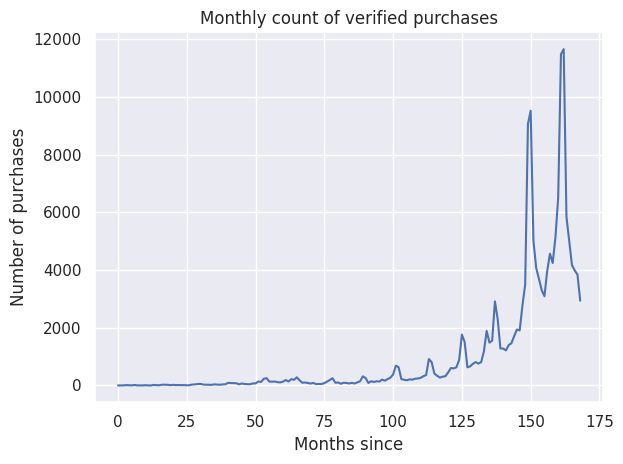

In [16]:
plt.figure(num=4)
monthly_transaction_count['purchase_count'].plot(title="Monthly count of verified purchases")
plt.xlabel('Months since')
plt.ylabel('Number of purchases')
plt.tight_layout()
plt.grid(True)
plt.show()

In [17]:
month_subseries_count = monthly_transaction_count.copy()
month_subseries_count['month'] = month_subseries_count['timestamp:float'].dt.month

foo = month_subseries_count.groupby(by='month')['purchase_count'].sum().reset_index(name='purchase_count')
foo.head(12)

,month,purchase_count
0,1,27533
1,2,13925
2,3,12135
3,4,10795
4,5,10530
5,6,10187
6,7,10650
7,8,9150
8,9,9505
9,10,11249


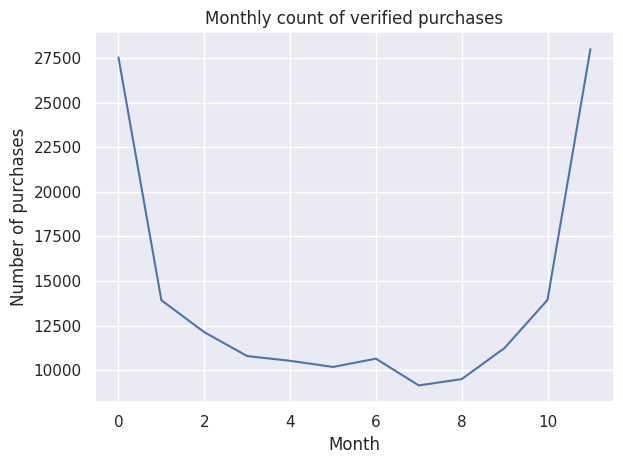

In [18]:
plt.figure(num=5)
foo['purchase_count'].plot(title="Monthly count of verified purchases")
plt.xlabel('Month')
plt.ylabel('Number of purchases')
plt.tight_layout()
plt.grid(True)
plt.show()

In [19]:
rating_counts = df['rating:float'].value_counts().sort_index()
rating_counts.head()

rating:float
1.0      4707
2.0      6298
3.0     16357
4.0     37445
5.0    102790
Name: count, dtype: int64

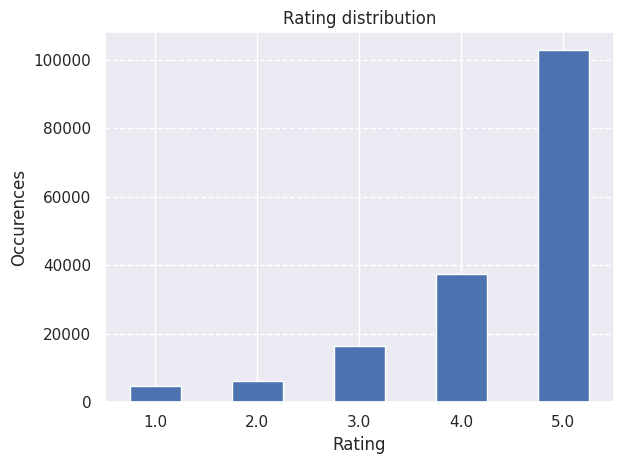

In [20]:
plt.figure(num=6)
rating_counts.plot(kind='bar')
plt.xlabel('Rating')
plt.ylabel('Occurences')
plt.title('Rating distribution')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

### 3.8 Subclasses

In [21]:
df2 = pd.read_csv('../../Amazon_Toys_and_Games/Amazon_Toys_and_Games.item', sep='\t')
df2.head(3)

,item_id:token,title:token,price:float,sales_type:token,sales_rank:float,brand:token,categories:token_seq
0,0,Little Red Tool Box: Magnetic Tabletop Learnin...,16.19,NaN,NaN,Scholastic,"'Toys & Games', 'Pretend Play', 'Dress Up & Pr..."
1,1,Dover Publications-Decorative Tile Designs Col...,1.44,"Arts, Crafts & Sewing",1009.0,Dover Pubns,"'Toys & Games', 'Arts & Crafts', 'Drawing & Sk..."
2,2,The Book of Impossible Objects: 25 Eye-Popping...,11.13,"Arts, Crafts & Sewing",1462.0,Klutz,"'Toys & Games', 'Novelty & Gag Toys', 'Magic K..."


In [22]:
subcategories_df = df2.dropna(subset=['categories:token_seq'])
subcategories_df.head(3)
subcategories_df['categories:token_seq'] = subcategories_df['categories:token_seq'].apply(lambda x: x.split(',')[1] if len(x.split(',')) > 1 else x.split(',')[0])
unique_parent_asins_in_subcategory = subcategories_df[['item_id:token', 'categories:token_seq']].drop_duplicates()
product_count_by_subcategory = unique_parent_asins_in_subcategory.groupby('categories:token_seq')['item_id:token'].count().sort_values(ascending=False)

In [23]:
product_count_by_subcategory.head(5)

categories:token_seq
'Toys & Games'         2975
'Games'                1107
'Building Toys'         889
'Animals & Figures'     608
'Pretend Play'          538
Name: item_id:token, dtype: int64

In [24]:
top_n_subcategories = product_count_by_subcategory.head(20)
others_count = product_count_by_subcategory.iloc[20:].sum()

if others_count > 0:
    top_n_subcategories['Other'] = others_count

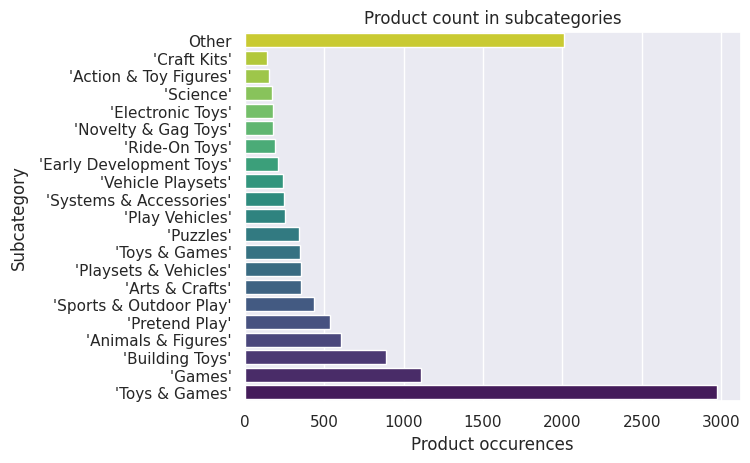

In [25]:
barplot = sns.barplot(x=top_n_subcategories.values, y=top_n_subcategories.index, palette="viridis", hue=top_n_subcategories.index, dodge=False, legend=False)
plt.xlabel('Product occurences')
plt.ylabel('Subcategory')
plt.title(f'Product count in subcategories')
plt.gca().invert_yaxis()